# **Notebook 2** - Inspecting & Processing Seismic Data

### MVP1 goals: Data inspection, preprocessing, visualizations

In Notebook 1, we learned how to discover seismic events, select stations, retrieve waveform data, and store the results as a reusable data product.

In this notebook, we take the next step: we inspect the retrieved waveforms and decide whether they are ready for analysis.

A waveform dataset is not automatically useful just because it was retrieved successfully. Some traces may have gaps, missing channels, unusual sampling rates, incomplete metadata, noisy records, or unavailable instrument response information. Before using the data for scientific interpretation, we need to check its quality and prepare it consistently.

In [36]:
# first we read the inventory and metadata that we saved in Notebook1_mvp1.ipynb
from obspy import read_inventory
st_inv = read_inventory("station_inventory.xml")

import pandas as pd
df = pd.read_csv("station_dataframe.csv")

import json
from obspy import UTCDateTime

with open("event_selection.json", "r") as f:
    event_selection = json.load(f)

event_time = UTCDateTime(event_selection["event_time"])
t1 = UTCDateTime(event_selection["start_time"])
t2 = UTCDateTime(event_selection["end_time"])
target_channel = event_selection["target_channel"]

df


,network,station,start_date,latitude,longitude,elevation,channel,sample_rate,data_available
0,US,NLWA,2006-07-05T00:00:00.000000Z,47.391700,-123.869100,640.0,HNZ,200.0,True
1,UW,BILS,2015-03-30T00:00:00.000000Z,47.539660,-124.251380,62.0,HNZ,200.0,True
2,UW,BLN,1980-01-11T00:00:00.000000Z,48.006624,-122.972646,601.0,HNZ,200.0,True
3,UW,ERW,1997-12-01T00:00:00.000000Z,48.453827,-122.626121,387.0,HNZ,200.0,True
4,UW,HURR,2017-05-10T00:00:00.000000Z,47.970350,-123.498710,1605.0,HNZ,200.0,True
5,UW,LWCK,2015-01-29T00:00:00.000000Z,46.277800,-124.053600,60.4,HNZ,200.0,True
6,UW,MAC,2018-06-25T00:00:00.000000Z,47.246700,-122.531800,112.5,HNZ,200.0,True
7,UW,OOW2,2015-03-03T00:00:00.000000Z,47.749190,-124.175440,741.0,HNZ,200.0,True
8,UW,QCDG,2011-11-16T00:00:00.000000Z,48.100020,-122.586960,52.2,HNZ,200.0,True
9,UW,QCEN,2012-06-14T00:00:00.000000Z,46.716350,-122.961900,55.4,HNZ,200.0,True


               network: US
               station: NLWA
              location: 20
               channel: HNZ
             starttime: 2018-11-19T11:07:59.735000Z
               endtime: 2018-11-19T11:11:28.110000Z
         sampling_rate: 200.0
                 delta: 0.005
                  npts: 41676
                 calib: 1.0
_fdsnws_dataselect_url: https://service.earthscope.org/fdsnws/dataselect/1/query
               _format: MSEED
                 mseed: AttribDict({'dataquality': 'M', 'number_of_records': 19, 'encoding': 'STEIM2', 'byteorder': '>', 'record_length': 512, 'filesize': 33792})
            processing: ['ObsPy 1.4.2: trim(endtime=UTCDateTime(2018, 11, 19, 11, 17, 13, 130000)::fill_value=None::nearest_sample=True::pad=False::starttime=UTCDateTime(2018, 11, 19, 11, 7, 13, 130000))']


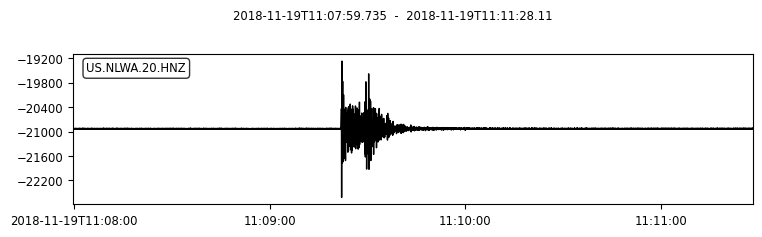

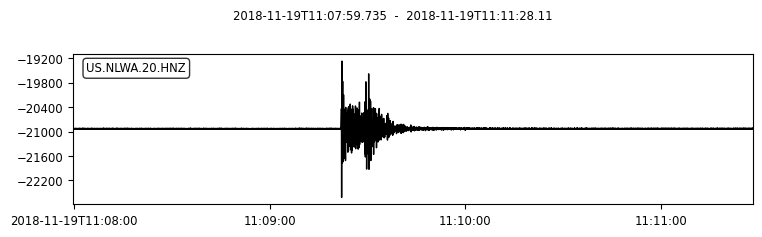

In [22]:
row_number = 0 # You can change this to any row number you want to retrieve

# Retrieve waveform data for a specific station and channel
from obspy.clients.fdsn import Client
client = Client("https://service.earthscope.org")
st = client.get_waveforms(network=df.iloc[row_number].network, 
                            station=df.iloc[row_number].station, location="*", 
                            channel='HNZ', starttime=t1, endtime=t2)

st.merge(method=1, fill_value="interpolate") # Merge the traces in the stream, filling gaps by interpolation
tr = st[0] 

print(tr.stats)
st.plot()

You just pulled real ground motion data from a station and plotted it. The ground motion data or seismogram records different waves that travel through the Earth at different speeds and therefore arrive at different times. The fastest wave arrives first (P-wave), followed by slower ones (Surface wave).

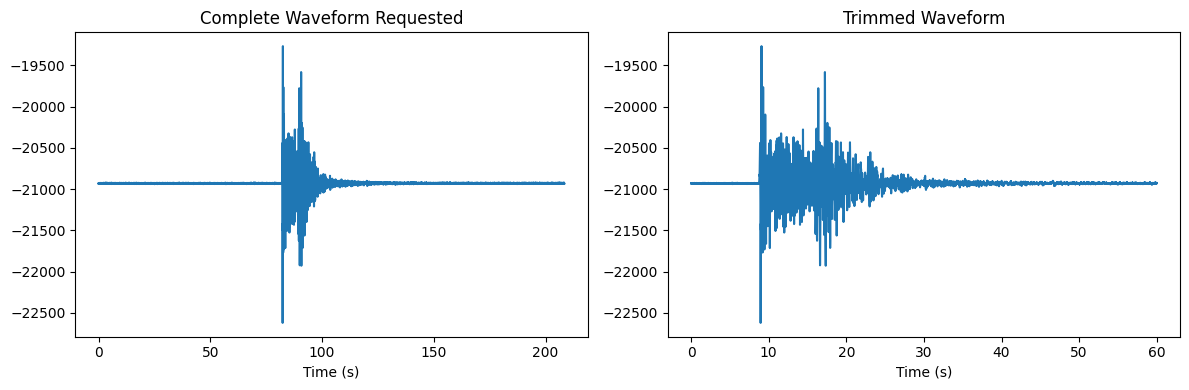

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.subplot(1,2,1)
plt.plot(tr.times(),tr.data)
plt.xlabel("Time (s)")
plt.title("Complete Waveform Requested")

# Trim the waveform data to a specific time window
pick_time1 = 120
pick_time2 = 180

tr_trim = tr.copy()  # Create a copy of the trace to trim
tr_trim.trim(starttime=t1+pick_time1, endtime=t1+pick_time2)

plt.subplot(1,2,2)
plt.plot(tr_trim.times(),tr_trim.data)
plt.xlabel("Time (s)")
plt.title("Trimmed Waveform")

plt.tight_layout()

#### **Data Interpretation**

In the plot above, the y-axis is raw digital counts, not ground motion. The instrument doesn't record accelaration or velocity directly. Ground motion moves a mass, that motion is converted to a voltage, and a digitizer turns the voltage into integer counts. The counts are proportional to ground motion, but the proportionality constant (and its frequency dependence) lives in the **instrument response**.

Text(0.5, 1.0, 'Waveform After Instrument Response Removal')

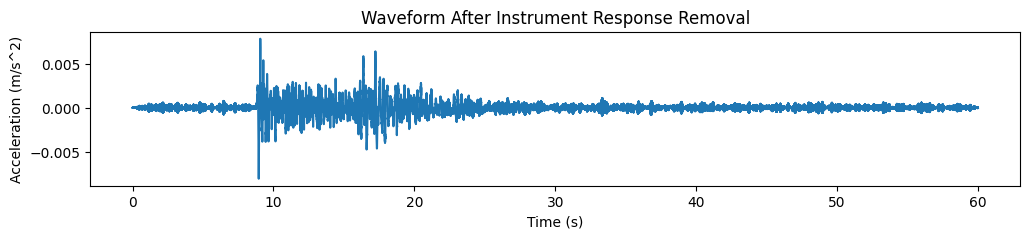

In [26]:

# To apply instrument response
tr_corrected = tr_trim.copy()
tr_corrected.remove_response(inventory=st_inv, output="ACC")  # Specify output units as velocity

plt.figure(figsize=(12, 2))
plt.plot(tr_corrected.times(), tr_corrected.data)
plt.xlabel("Time (s)")
plt.ylabel("Acceleration (m/s^2)")
plt.title("Waveform After Instrument Response Removal")

Next, we compute a spectrogram. A spectrogram shows how signal energy is distributed across frequency and time. This helps us choose a filter band: we can keep the frequency range where the earthquake signal is strong and reduce frequencies dominated by noise.

Text(0.5, 1.0, 'Spectrogram of Trimmed Waveform')

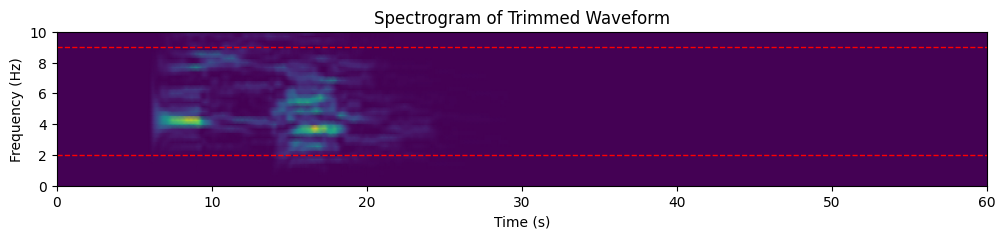

In [29]:
from scipy import signal
import numpy as np

# Sampling rate of the data
fs = tr_corrected.stats.sampling_rate

# Set window size and overlap for the spectrogram
nperseg = 700
noverlap = nperseg - 10

# Compute the spectrogram
f, t_spec, Sxx = signal.spectrogram(tr_corrected.data, fs=fs, nperseg=nperseg, noverlap=noverlap)

# Adjust spectrogram time axis to match slice duration
t_spec = np.linspace(0, tr_corrected.times()[-1], Sxx.shape[1])

plt.figure(figsize=(12, 2))
plt.pcolormesh(t_spec, f, np.abs(Sxx), shading='gouraud')
plt.ylim(0, 10)
plt.axhline(y=2, color='red', linestyle='--', linewidth=1)
plt.axhline(y=9, color='red', linestyle='--', linewidth=1)
plt.xlabel("Time (s)")
plt.ylabel("Frequency (Hz)")
plt.title("Spectrogram of Trimmed Waveform")

Below, we will do a bandpass filtering to remove frequency components outside the most prominent range.

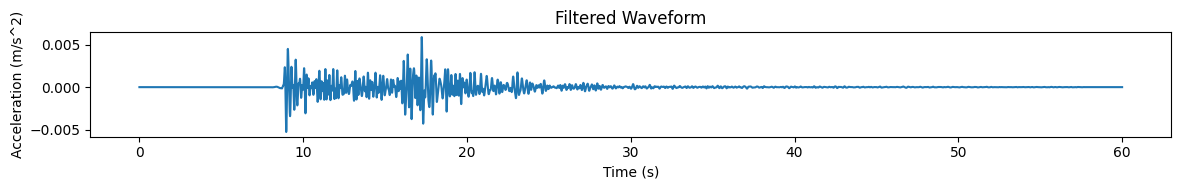

In [31]:
tr_filt = tr_corrected.copy()

# Bandpass between 1 and 10 Hz, 4-pole Butterworth, zero-phase
tr_filt.detrend("demean")      # remove DC offset
tr_filt.detrend("linear")      # remove linear trend
tr_filt.taper(max_percentage=0.05, type="hann")   # taper the ends to zero
tr_filt.filter("bandpass",
               freqmin=2.0,
               freqmax=9.0,
               corners=4,
               zerophase=True)

plt.figure(figsize=(12, 2))
plt.plot(tr_filt.times(), tr_filt.data)
plt.xlabel("Time (s)")
plt.ylabel("Acceleration (m/s^2)")
plt.title("Filtered Waveform")
plt.tight_layout()